# CSE 150A: Bayesian Network for Programming Skill Prediction

**Team:** Iha Gadiya, Ioanna Gkerdouki, Lianna Lim, Ved Panse, William Diego

**Goal:** Model how AI tool usage influences programming skill (proxied by salary)

## Conditional Independence Testing (Lianna)


In [49]:
import pandas as pd

data_path = "/cleaned_stackoverflow_bn_data.csv"

data = pd.read_csv(data_path)

df = pd.DataFrame(data)

# Creating contingency tables
table_YC_YCP = pd.crosstab(df['YearsCode'], df['YearsCodePro'])
table_AI_CCY = pd.crosstab(df['AISelect'], df['ConvertedCompYearly'])
table_YC_YA = pd.crosstab(df['YearsCode'], df['CodingActivities'])
table_DT_CCY = pd.crosstab(df['DevType'], df['ConvertedCompYearly'])


print(table_YC_YCP)
print("\n")
print(table_AI_CCY)
print("\n")
print(table_YC_YA)
print("\n")
print(table_DT_CCY)


YearsCodePro  high  low  medium
YearsCode                      
high           596   17     217
low              0    2       0
medium           0   69     205


ConvertedCompYearly  high  low  medium  very_high
AISelect                                         
no                     88  102     115        117
plan_to                68   71      73         84
yes                    85  100      92        111


CodingActivities  codes_as_hobby  no_code_as_hobby
YearsCode                                         
high                         607               223
low                            1                 1
medium                       176                98


ConvertedCompYearly  high  low  medium  very_high
DevType                                          
advocate                1    1       1          4
applications           12   27      22         19
back_end               68   43      68        125
enbedded                9   12      14          9
experience              4    

In [51]:
from scipy.stats import chi2_contingency

# YearsCode vs YearsCodePro
chi2, p, dof, expected = chi2_contingency(table_YC_YCP)

print("YearsCode vs YearsCodePro")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print()

# AISelect vs ConvertedCompYearly
chi2, p, dof, expected = chi2_contingency(table_AI_CCY)

print("AISelect vs ConvertedCompYearly")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print()

# YearsCode vs CodingActivities
chi2, p, dof, expected = chi2_contingency(table_YC_YA)

print("YearsCode vs CodingActivities")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print()

# DevType vs ConvertedCompYearly
chi2, p, dof, expected = chi2_contingency(table_DT_CCY)

print("DevType vs ConvertedCompYearly")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")

YearsCode vs YearsCodePro
Chi-Square Statistic: 486.7506
P-Value: 0.0000

AISelect vs ConvertedCompYearly
Chi-Square Statistic: 1.7813
P-Value: 0.9387

YearsCode vs CodingActivities
Chi-Square Statistic: 8.3280
P-Value: 0.0155

DevType vs ConvertedCompYearly
Chi-Square Statistic: 76.1941
P-Value: 0.0000


Chi-square tests were used to evaluate dependencies between variables and justify the Bayesian Network DAG structure.

YearsCode and YearsCodePro showed a very strong dependency (χ² = 486.7506, p < 0.001), supporting the edge YearsCode to YearsCodePro. YearsCode and CodingActivities also showed a statistically significant relationship (p = 0.0155), supporting the edge YearsCode to CodingActivities. DevType and ConvertedCompYearly showed strong dependency as well (χ² = 76.1941, p ≈ 0), supporting the edge DevType to ConvertedCompYearly.

In contrast, AISelect and ConvertedCompYearly showed weak evidence of dependency (p = 0.9387). However, we kept the edge AISelect to ConvertedCompYearly because AI assisted coding usage is the main focus of the project and may still have more subtle probabilistic effects not noticible by pairwise testing alone.


## DAG Visualization


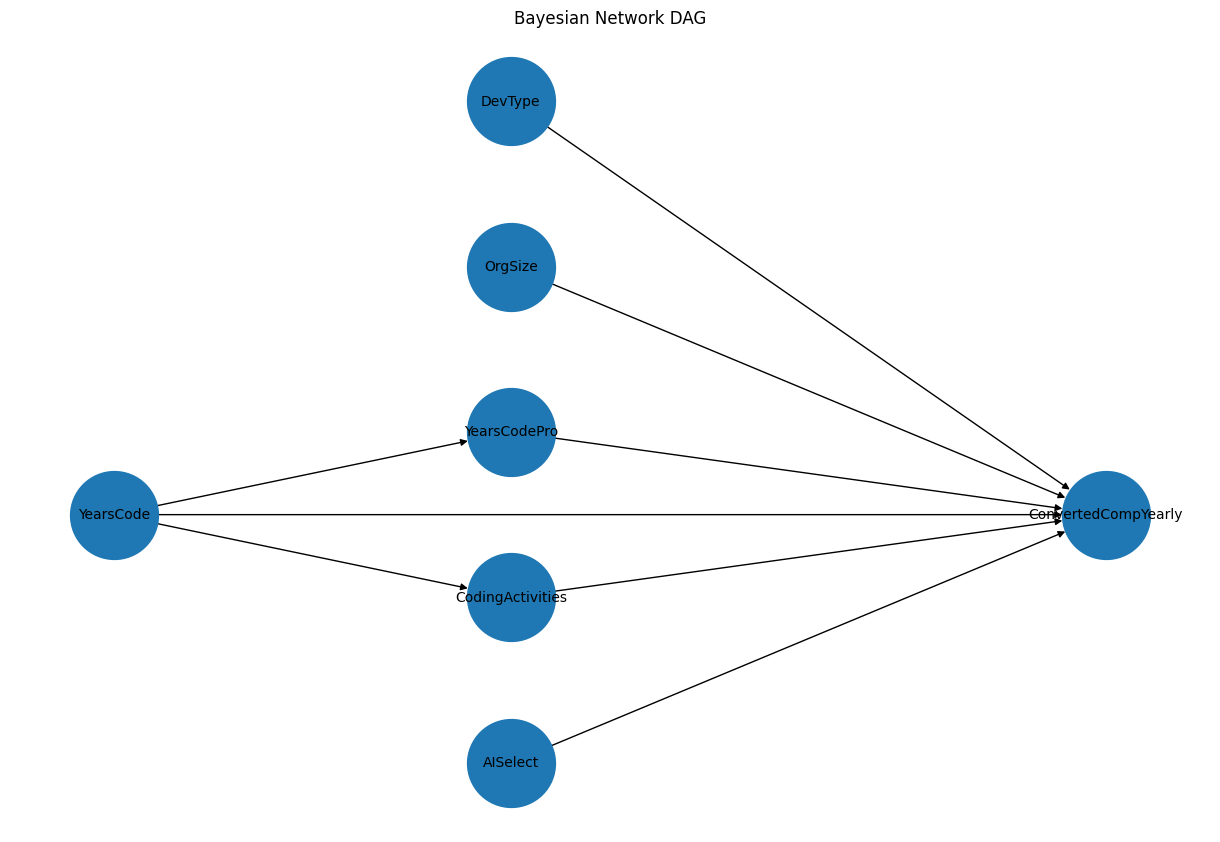

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
edges = [
    ("YearsCode", "YearsCodePro"),
    ("YearsCode", "CodingActivities"),
    ("YearsCodePro", "ConvertedCompYearly"),
    ("YearsCode", "ConvertedCompYearly"),
    ("AISelect", "ConvertedCompYearly"),
    ("CodingActivities", "ConvertedCompYearly"),
    ("OrgSize", "ConvertedCompYearly"),
    ("DevType", "ConvertedCompYearly")
]
G.add_edges_from(edges)

plt.figure(figsize=(12, 8))

pos = {
    "YearsCode": (0, 0),
    "YearsCodePro": (2, 1),
    "CodingActivities": (2, -1),
    "AISelect": (2, -3),
    "OrgSize": (2, 3),
    "DevType": (2, 5),
    "ConvertedCompYearly": (5, 0)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    arrows=True,
    node_size=4000,
    font_size=10
)

plt.title("Bayesian Network DAG")
plt.show()

YearsCode was connected to YearsCodePro because overall coding experience is expected to influence professional programming experience. YearsCode was also connected to CodingActivities since developers with more experience may be more likely to participate in coding related activities outside of work.

ConvertedCompYearly was modeled as the target variable and proxy for programming skill. It was connected to YearsCode and YearsCodePro because compensation is often associated with programming experience. CodingActivities was also connected to ConvertedCompYearly since additional coding practice may influence skill development and salary outcomes.

AISelect was connected to ConvertedCompYearly because the project focuses on how AI assisted coding tools may influence programming skill and developer outcomes. OrgSize and DevType were connected to ConvertedCompYearly because salary may vary depending on company size and developer role.

The network structure was kept relatively simple to reduce CPT complexity while still capturing the main relationships in the dataset.

## Part 4: Evaluation Functions (Iha)

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

def get_trainTestSplit(dataLink):
    #given this data is filtered
    data = pd.read_csv(dataLink)

    train_data, test_data = train_test_split(
        data,
        test_size=0.3,
        random_state=42
    )

    return train_data, test_data

In [ ]:
#Set up baseline
#Probability of most common yearly comp ranege
def baseLine_calc(data):
    q1 = data['ConvertedCompYearly'].quantile(0.25)
    q2 = data['ConvertedCompYearly'].quantile(0.5)
    q3 = data['ConvertedCompYearly'].quantile(0.75)

    counts = [0, 0, 0, 0]

    for val in data['ConvertedCompYearly']:
        if val < q1:
            counts[0]+=1
        elif val >= q1 and val < q2:
            counts[1]+= 1
        elif val >= q2 and val < q3:
            counts[2]+= 1
        else:
            counts[3]+= 1

    return max(counts)/sum(counts)

In [ ]:
def accuracy_test(predicted_labels, test_data):
    correct = 0
    total = len(predicted_labels)

    true_labels = test_data['ConvertedCompYearly'].values

    for i in range(total):
        if true_labels[i] == predicted_labels[i]:
            correct += 1


    return correct/total

## Part 3: Bayesian Network Structure & Coding (Ioanna)

In [21]:
# Imports for Bayesian Network
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination
import numpy as np

In [22]:
# Load the cleaned data
DATA_PATH = '../cleaned_data/cleaned_stackoverflow_bn_data.csv'

data = pd.read_csv(DATA_PATH)

# Drop Country column (used for filtering, not in our DAG)
data = data.drop(columns=['Country'])

print(f"Total rows: {len(data)}")
print(f"Columns: {list(data.columns)}")
print(f"\nSample data:")
data.head()

FileNotFoundError: [Errno 2] No such file or directory: '../cleaned_data/cleaned_stackoverflow_bn_data.csv'

In [ ]:
# Check unique values for each variable
print("Unique values per column:")
for col in data.columns:
    print(f"  {col}: {data[col].unique()}")

In [ ]:
# Define the DAG structure based on our proposal
# Format: (parent, child) - parent influences child

edges = [
    ('YearsCode', 'YearsCodePro'),         # Total experience -> Professional experience
    ('YearsCode', 'CodingActivities'),     # Total experience -> Coding activities
    ('YearsCode', 'ConvertedCompYearly'),  # Total experience -> Salary
    ('YearsCodePro', 'ConvertedCompYearly'),   # Professional exp -> Salary
    ('AISelect', 'ConvertedCompYearly'),       # AI usage -> Salary
    ('CodingActivities', 'ConvertedCompYearly'),  # Activities -> Salary
    ('OrgSize', 'ConvertedCompYearly'),        # Company size -> Salary
    ('DevType', 'ConvertedCompYearly'),        # Role type -> Salary
]

# Create the Bayesian Network
model = DiscreteBayesianNetwork(edges)

print("Bayesian Network created!")
print(f"Nodes: {list(model.nodes())}")
print(f"Edges: {list(model.edges())}")

In [ ]:
# Split data into train and test sets
train_data, test_data = get_trainTestSplit(DATA_PATH)

# Drop Country from train/test as well
train_data = train_data.drop(columns=['Country'])
test_data = test_data.drop(columns=['Country'])

print(f"Training set: {len(train_data)} rows")
print(f"Test set: {len(test_data)} rows")

In [ ]:
# Fit the model using Maximum Likelihood Estimation (MLE)
# MLE formula: P(X | Parents) = count(X, Parents) / count(Parents)

model.fit(train_data, estimator=DiscreteMLE())

print("Model fitted with MLE!")
print(f"Model is valid: {model.check_model()}")

In [ ]:
# View the Conditional Probability Tables (CPTs)
print("=" * 60)
print("CONDITIONAL PROBABILITY TABLES")
print("=" * 60)

for cpd in model.get_cpds():
    print(f"\n--- CPT for {cpd.variable} ---")
    parents = cpd.get_evidence()
    if parents:
        print(f"Parents: {parents}")
    else:
        print("Parents: None (root node)")
    print(cpd)

## Inference: Query the Model

In [ ]:
# Create inference engine
inference = VariableElimination(model)

In [ ]:
# Query 1: P(Salary | uses AI tools)
print("P(ConvertedCompYearly | AISelect = yes)")
print("="*40)
result = inference.query(['ConvertedCompYearly'], evidence={'AISelect': 'yes'})
print(result)

In [ ]:
# Query 2: P(Salary | doesn't use AI tools)
print("P(ConvertedCompYearly | AISelect = no)")
print("="*40)
result = inference.query(['ConvertedCompYearly'], evidence={'AISelect': 'no'})
print(result)

In [ ]:
# Query 3: P(Salary | high experience AND uses AI)
print("P(ConvertedCompYearly | YearsCodePro=high, AISelect=yes)")
print("="*50)
result = inference.query(
    ['ConvertedCompYearly'],
    evidence={'YearsCodePro': 'high', 'AISelect': 'yes'}
)
print(result)

## AI Usage Effect Analysis

In [ ]:
# Compare salary distributions across AI usage levels
print("=" * 60)
print("AI USAGE EFFECT ON PROGRAMMING SKILL (Salary Proxy)")
print("=" * 60)

ai_states = data['AISelect'].unique()

for ai_state in ai_states:
    print(f"\nP(Salary | AISelect = {ai_state}):")
    result = inference.query(['ConvertedCompYearly'], evidence={'AISelect': ai_state})

    # Extract probabilities
    for i, state in enumerate(result.state_names['ConvertedCompYearly']):
        prob = result.values[i]
        print(f"  {state}: {prob:.3f}")

## Model Evaluation: Predictions on Test Set

In [ ]:
def predict_salary(row, model, inference):
    """
    Predict most likely salary category given other variables.
    Returns None if evidence contains states not seen during training.
    """
    evidence = {
        'YearsCode': row['YearsCode'],
        'YearsCodePro': row['YearsCodePro'],
        'AISelect': row['AISelect'],
        'CodingActivities': row['CodingActivities'],
        'OrgSize': row['OrgSize'],
        'DevType': row['DevType'],
    }

    try:
        result = inference.query(['ConvertedCompYearly'], evidence=evidence)

        # Get the state with highest probability
        max_idx = np.argmax(result.values)
        predicted = result.state_names['ConvertedCompYearly'][max_idx]

        return predicted
    except KeyError:
        # Handle unseen states in test data
        return None

In [ ]:
# Make predictions on test set
print("Making predictions on test set...")

predictions = []
skipped = 0
for idx, row in test_data.iterrows():
    pred = predict_salary(row, model, inference)
    if pred is None:
        skipped += 1
    predictions.append(pred)

print(f"Made {len(predictions) - skipped} predictions")
if skipped > 0:
    print(f"Skipped {skipped} rows with unseen states")

In [ ]:
# Calculate accuracy (excluding rows with unseen states)
actual = test_data['ConvertedCompYearly'].values
valid_pairs = [(p, a) for p, a in zip(predictions, actual) if p is not None]
correct = sum(1 for p, a in valid_pairs if p == a)
accuracy = correct / len(valid_pairs) if valid_pairs else 0

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"\nBayesian Network Accuracy: {accuracy:.2%}")
print(f"Correct predictions: {correct} / {len(valid_pairs)}")

In [ ]:
# Compare to baseline (majority class)
# Since data is already discretized, find most common class
majority_class = train_data['ConvertedCompYearly'].value_counts().idxmax()
baseline_correct = sum(1 for a in actual if a == majority_class)
baseline_accuracy = baseline_correct / len(actual)

print(f"Baseline (majority class '{majority_class}'): {baseline_accuracy:.2%}")
print(f"\nImprovement over baseline: {(accuracy - baseline_accuracy)*100:.1f} percentage points")

## Summary

This Bayesian Network models how various factors influence programming skill (proxied by yearly compensation):

**Key Findings:**
- The model captures conditional dependencies between experience, AI usage, and compensation
- We can query P(Skill | AI usage) to analyze AI tool effects
- Model accuracy compared against majority class baseline